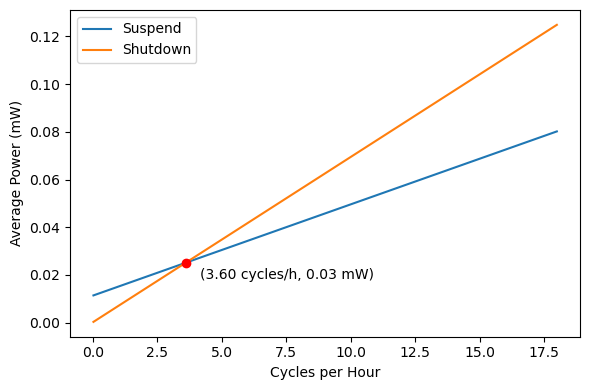

Intersection at Cycles/Hour=3.595629, Avg Power=0.025103 mW


In [20]:
import numpy as np
import matplotlib.pyplot as plt


E_cycle = 14.16871621
t_cycle = 35.538

E_boot = 10.77697843
t_boot = 29.054

P_shutdown = 2e-4
P_suspend = 0.011154 + 2e-4

def suspend(duration):
    return (E_cycle + P_suspend * (duration - t_cycle)) / duration

def shutdown(duration):
    return (E_cycle + E_boot + P_shutdown * (duration - t_cycle - t_boot)) / duration

durates = np.arange(200, 200000, 1)
x = 3600 / durates
y1 = suspend(durates)
y2 = shutdown(durates)

# ---- Find intersection ----
diff = y1 - y2
idx = np.where(np.diff(np.sign(diff)))[0]

if len(idx) == 0:
    raise ValueError('No intersection found in the given range.')

i = idx[0]
d0, d1 = durates[i], durates[i+1]
f0, f1 = diff[i], diff[i+1]

# Linear interpolation for more precise crossing
d_cross = d0 - f0 * (d1 - d0) / (f1 - f0)
x_cross = 3600 / d_cross
y_cross = suspend(d_cross)

# ---- Plot ----
plt.figure(figsize=(6, 4))
plt.plot(x, y1, label='Suspend')
plt.plot(x, y2, label='Shutdown')
plt.scatter([x_cross], [y_cross], color='red', zorder=5)
plt.annotate(f'({x_cross:.2f} cycles/h, {y_cross:.2f} mW)',
             (x_cross, y_cross),
             textcoords='offset points',
             xytext=(10, -12))

plt.legend()
plt.xlabel('Cycles per Hour')
plt.ylabel('Average Power (mW)')
plt.tight_layout()
plt.show()

print(f'Intersection at Cycles/Hour={x_cross:.6f}, Avg Power={y_cross:.6f} mW')


### Calculate night rate

1. 720p int8 inference

In [28]:
import datetime

E_cycle = 14.16871621
t_cycle = 35.538

E_boot = 10.77697843
t_boot = 29.054

P_shutdown = 2e-4
P_suspend = 0.011154 + 2e-4

C = 470
V_initial = 3
V_final = 1

def calculate_rate_shutdown(duration):
    '''
    duration: in seconds
    '''
    assert duration > t_cycle + t_boot
    total_duration = 0
    v = V_initial
    count = 1
    while v > V_final:
        E_cap = 0.5 * C * v**2
        E_cap -= (E_cycle + E_boot)  # energy consumed in one cycle + boot
        E_cap -= P_shutdown * (duration - t_cycle - t_boot)  # energy consumed in shutdown
        v = (2 * E_cap / C)**0.5
        count += 1
        total_duration += duration
    print(f'Cycle {count}: Voltage={v:.4f} V, duration', str(datetime.timedelta(seconds=total_duration)))
        
def calculate_rate_suspend(duration):
    '''
    duration: in seconds
    '''
    assert duration > t_cycle
    total_duration = 0
    v = V_initial
    count = 1
    while v > V_final:
        E_cap = 0.5 * C * v**2
        E_cap -= E_cycle  # energy consumed in one cycle
        E_cap -= P_suspend * (duration - t_cycle)  # energy consumed in suspend
        v = (2 * E_cap / C)**0.5
        count += 1
        total_duration += duration
    print(f'Cycle {count}: Voltage={v:.4f} V, duration', str(datetime.timedelta(seconds=total_duration)))
        
calculate_rate_shutdown(580)
calculate_rate_suspend(600)


Cycle 77: Voltage=0.9482 V, duration 12:14:40
Cycle 93: Voltage=0.9716 V, duration 15:20:00
